In [25]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
res = requests.get("https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=SINGF&outputsize=full&apikey=5VDAZ70Y9F6SCD1P")
res

<Response [200]>

In [51]:
res_json = res.json()
res_json

{'Meta Data': {'1. Information': 'Daily Prices (open, high, low, close) and Volumes',
  '2. Symbol': 'SINGF',
  '3. Last Refreshed': '2021-09-03',
  '4. Output Size': 'Full size',
  '5. Time Zone': 'US/Eastern'},
 'Time Series (Daily)': {'2021-09-03': {'1. open': '3.6500',
   '2. high': '3.6500',
   '3. low': '3.6500',
   '4. close': '3.6500',
   '5. volume': '1204'},
  '2021-09-02': {'1. open': '3.7000',
   '2. high': '3.7900',
   '3. low': '3.7000',
   '4. close': '3.7100',
   '5. volume': '1194'},
  '2021-09-01': {'1. open': '3.6500',
   '2. high': '3.6500',
   '3. low': '3.6500',
   '4. close': '3.6500',
   '5. volume': '10'},
  '2021-08-31': {'1. open': '3.7250',
   '2. high': '3.8000',
   '3. low': '3.6500',
   '4. close': '3.6500',
   '5. volume': '4064'},
  '2021-08-30': {'1. open': '3.7100',
   '2. high': '3.7100',
   '3. low': '3.7100',
   '4. close': '3.7100',
   '5. volume': '31060'},
  '2021-08-27': {'1. open': '3.7000',
   '2. high': '3.7000',
   '3. low': '3.7000',
   '4

In [52]:
sia_df = pd.DataFrame.from_dict(res_json['Time Series (Daily)']).T
sia_df

,1. open,2. high,3. low,4. close,5. volume
2021-09-03,3.6500,3.6500,3.6500,3.6500,1204
2021-09-02,3.7000,3.7900,3.7000,3.7100,1194
2021-09-01,3.6500,3.6500,3.6500,3.6500,10
2021-08-31,3.7250,3.8000,3.6500,3.6500,4064
2021-08-30,3.7100,3.7100,3.7100,3.7100,31060
...,...,...,...,...,...
2007-07-20,12.6500,12.6500,12.6500,12.6500,1400
2007-07-19,12.7000,12.7000,12.7000,12.7000,2455
2007-07-18,12.4000,12.4500,12.4000,12.4000,5300
2007-07-17,12.9000,12.9000,12.9000,12.9000,4100


In [53]:
sia_df.index

Index(['2021-09-03', '2021-09-02', '2021-09-01', '2021-08-31', '2021-08-30',
       '2021-08-27', '2021-08-26', '2021-08-25', '2021-08-24', '2021-08-23',
       ...
       '2007-07-27', '2007-07-26', '2007-07-25', '2007-07-24', '2007-07-23',
       '2007-07-20', '2007-07-19', '2007-07-18', '2007-07-17', '2007-07-16'],
      dtype='object', length=3502)

In [54]:
sia_df.index = pd.to_datetime(sia_df.index)
sia_df.index

DatetimeIndex(['2021-09-03', '2021-09-02', '2021-09-01', '2021-08-31',
               '2021-08-30', '2021-08-27', '2021-08-26', '2021-08-25',
               '2021-08-24', '2021-08-23',
               ...
               '2007-07-27', '2007-07-26', '2007-07-25', '2007-07-24',
               '2007-07-23', '2007-07-20', '2007-07-19', '2007-07-18',
               '2007-07-17', '2007-07-16'],
              dtype='datetime64[ns]', length=3502, freq=None)

In [55]:
sia_df = sia_df.astype('float32')
sia_df

,1. open,2. high,3. low,4. close,5. volume
2021-09-03,3.650,3.65,3.65,3.65,1204.0
2021-09-02,3.700,3.79,3.70,3.71,1194.0
2021-09-01,3.650,3.65,3.65,3.65,10.0
2021-08-31,3.725,3.80,3.65,3.65,4064.0
2021-08-30,3.710,3.71,3.71,3.71,31060.0
...,...,...,...,...,...
2007-07-20,12.650,12.65,12.65,12.65,1400.0
2007-07-19,12.700,12.70,12.70,12.70,2455.0
2007-07-18,12.400,12.45,12.40,12.40,5300.0
2007-07-17,12.900,12.90,12.90,12.90,4100.0


In [56]:
gme_df[:'2018-01-01']

,1. open,2. high,3. low,4. close,5. volume
2021-09-03,212.050003,216.270004,198.839996,202.750000,2664005.0
2021-09-02,213.860001,214.800003,206.300003,213.520004,1855618.0
2021-09-01,224.000000,231.438995,208.020004,212.970001,4453782.0
2021-08-31,212.699997,222.300003,211.460007,218.240005,3574687.0
2021-08-30,205.000000,218.190002,203.020004,209.199997,3309584.0
...,...,...,...,...,...
2018-01-08,18.799999,19.400000,18.799999,19.230000,3624092.0
2018-01-05,18.379999,18.730000,18.219999,18.680000,2985380.0
2018-01-04,18.200001,18.379999,17.959999,18.320000,2728357.0
2018-01-03,18.290001,18.370001,17.920000,18.200001,3770304.0


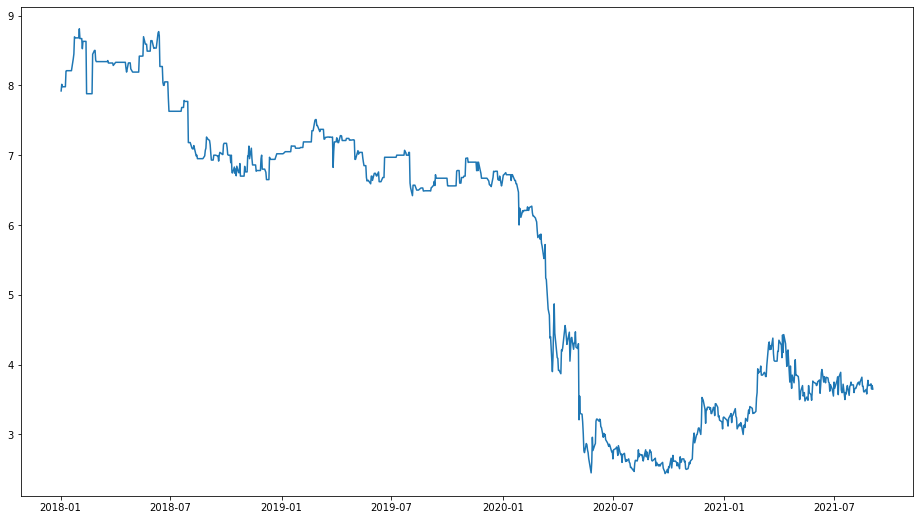

In [58]:
plt.figure(figsize = (16,9))
plt.plot(sia_df[:'2018-01-01']['1. open'])

In [59]:
# look for a data api on a topic that you like
# collect data through the API for analysis

# tell me an interesting data story through the API


In [ ]:
# email me if you have doubts or have a challenge implementing the idea technically
# solo work

# weightage more on originality and interestingness
# interesting topic not so good technique > pure technique but not interesting

# 75 

# Deadline extendable if overwhelmed